## Loading

In [5]:
import spikeinterface as si
import RCP_analysis as rcp
from RCP_analysis.python.functions.config_loading import *

# Config
RATES = PARAMS.NPRW_rate_est
BIN_MS     = RATES.get("bin_ms")
SIGMA_MS   = RATES.get("sigma_ms")
THRESH     = RATES.get("detect_threshold")
PEAK_SIGN  = RATES.get("peak_sign")

NPRW_CKPT_OUT = OUT_BASE / "checkpoints" / "NPRW"
        
global_job_kwargs = dict(n_jobs=PARAMS.parallel_jobs, chunk_duration=PARAMS.chunk)
si.set_global_job_kwargs(**global_job_kwargs)

INDEX = 3

# 2) Find sessions and load data from each Intan folder
sess_folders = rcp.list_intan_sessions(INTAN_ROOT)
print(f"Found Intan sessions: {len(sess_folders)}")

nprw_pp_folders = sorted(NPRW_CKPT_OUT.glob("pp_*"))
nprw_pp_folder = nprw_pp_folders[INDEX]
print(nprw_pp_folder)

nprw_peaks_folders = sorted(NPRW_CKPT_OUT.glob("rates__*.npz"))
nprw_peaks_folder = nprw_peaks_folders[INDEX]
print(nprw_peaks_folder)

# for sess in sess_folders[:]: # Can tweak here to isolate sessions
rec_nprw = si.load(nprw_pp_folder)

def _parse_SI_peaks(peaks, n_channels: int) -> tuple[dict[int, np.ndarray], dict[int, np.ndarray]]:
    peak_times: dict[int, np.ndarray] = {i: np.array([], dtype=np.int64) for i in range(n_channels)}
    peak_amp: dict[int, np.ndarray] = {i: np.array([], dtype=np.float32) for i in range(n_channels)}

    ch_idx = peaks["channel_index"]
    for i in np.unique(ch_idx):
        ii = int(i)
        if ii >= n_channels:
            continue
        m = (ch_idx == i)
        peak_times[ii] = peaks["sample_index"][m]
        peak_amp[ii] = peaks["amplitude"][m]

    return peak_times, peak_amp

nprw_peaks_si_obj = np.load(nprw_peaks_folder, allow_pickle=True)
nprw_peak_samps, nprw_peak_amps = _parse_SI_peaks(nprw_peaks_si_obj['peaks'], 128)
nprw_peak_ms   = {k: (v / 30000)   * 1000.0 for k, v in nprw_peak_samps.items()}

SESSION = nprw_peaks_si_obj['meta'].item()['session']

NPRW_SORT_CKPT_OUT = OUT_BASE / "checkpoints" / "sorting_results" / SESSION / "NPRW" / "folder_KS4"
NPRW_SORT_ANALYZE_CKPT_OUT = OUT_BASE / "checkpoints" / "sorting_results" / SESSION / "NPRW" / "my_sorting_analyzer"

PERI_ROOT = OUT_BASE / "checkpoints" / "PeriStim"
STIM_PERI_ROOT  = PERI_ROOT / "stim_reaches"

stim_dir = STIM_PERI_ROOT #/ 'target_A'

session_name = nprw_pp_folder.name.split("NRR_RW", 1)[1]
matches = list(stim_dir.glob(f"peristim__NRR_RW{session_name}__BR_*.npz"))
stim_npz_path = matches[0]  # or iterate if multiple
stim_npz = np.load(stim_npz_path, allow_pickle=True)

# CONTROL_PERI_ROOT  = PERI_ROOT / "control_reaches"
# control_dir = CONTROL_PERI_ROOT / 'target_A'
# control_npz_path = control_dir / FILE
# stim_npz = np.load(control_npz_path, allow_pickle=True)

print(stim_npz)

Found Intan sessions: 63
/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/pp_local_30_150__interp_NRR_RW026_260324_122433
/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/NPRW/rates__NRR_RW026_260324_122433__bin20ms_sigma20ms.npz
NpzFile '/media/bryan/Expansion/Nike/20260324_NRR_RW026/results/checkpoints/PeriStim/stim_reaches/peristim__NRR_RW026_260324_122433__BR_004.npz' with keys: sess, br_idx, overall_title, meta, ua_meta...


In [6]:
stim_npz = np.load(stim_npz_path, allow_pickle=True)
rates_ch_hz = stim_npz['NPRW_rates_hz']
edges_ms   = stim_npz["NPRW_edges_ms"]
centers_ms = stim_npz["NPRW_rel_t"]

In [7]:
# z score per channel
mu  = np.nanmean(rates_ch_hz[:, :, :], axis=2, keepdims=True)
sig = np.nanstd (rates_ch_hz[:, :, :], axis=2, keepdims=True)
sig = np.clip(sig, 1e-6, None)
rates_ch_z = (rates_ch_hz - mu) / sig
psth_z = np.nanmean(rates_ch_z, axis=0)

X = psth_z
t = centers_ms

X_finite = np.where(np.isfinite(X), X, -np.inf)
peak_idx = np.argmax(X_finite, axis=1)
peak_time_ms = t[peak_idx]
peak_val = np.max(X_finite, axis=1)

z_thresh = 0  # tune (0.5–1.5 is common)
responsive = np.isfinite(peak_val) & (peak_val >= z_thresh)

order_resp = np.argsort(peak_time_ms[responsive])  # earliest first
order = np.concatenate([np.where(responsive)[0][order_resp],
                        np.where(~responsive)[0]])

psth_ch_sorted = psth_z[order]

In [8]:
def pad_bins_to_edges(Z, centers_ms, edges_ms, tol=1e-6):
    # Z: (n_ch, n_centers)
    # edges_ms: (n_edges,) -> expects Z to have (n_edges-1) columns
    centers_from_edges = 0.5 * (edges_ms[:-1] + edges_ms[1:])  # (n_edges-1,)
    out = np.full((Z.shape[0], centers_from_edges.size), np.nan, dtype=float)

    # map each provided center to the nearest edge-center
    idx = np.full(centers_ms.size, -1, dtype=int)
    for j, c in enumerate(centers_ms):
        k = int(np.argmin(np.abs(centers_from_edges - c)))
        if abs(centers_from_edges[k] - c) <= tol:
            idx[j] = k

    if np.any(idx < 0):
        bad = centers_ms[idx < 0]
        raise ValueError(f"Some centers did not match edge-centers (tol={tol}): {bad[:10]}")

    out[:, idx] = Z
    return out, centers_from_edges

psth_plot, centers_from_edges = pad_bins_to_edges(psth_ch_sorted, centers_ms, edges_ms, tol=1e-3)

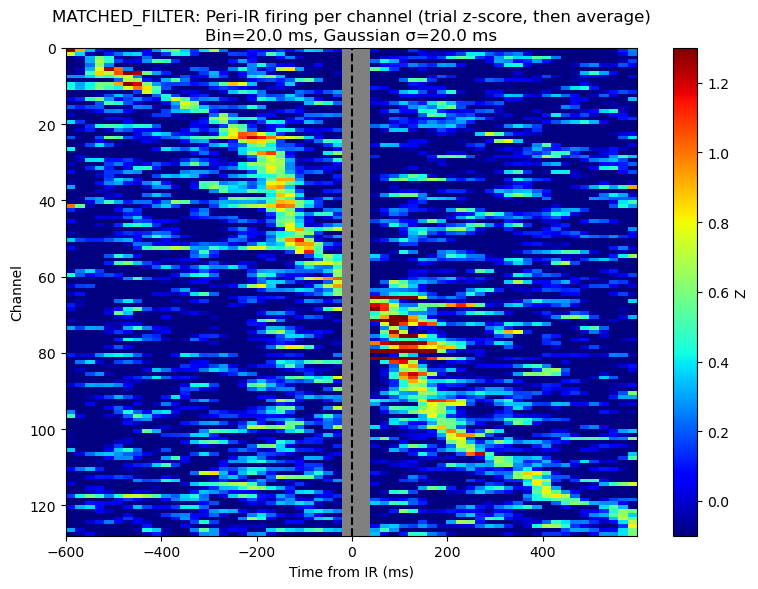

In [9]:
%matplotlib inline
# plot
n_ch = psth_plot.shape[0]
y_edges = np.arange(n_ch + 1)

fig, ax = plt.subplots(figsize=(8,6))
ax.set_facecolor("0.5")
pc = ax.pcolormesh(
    edges_ms,
    y_edges,
    psth_plot,
    shading="flat",
    cmap="jet",
    vmin=-0.1,
    vmax=1.3,
)

ax.invert_yaxis()
ax.axvline(0, linestyle="--", color="black")
ax.set_ylim(n_ch, 0)
ax.set_xlabel("Time from IR (ms)")
ax.set_ylabel("Channel")
ax.set_title(f"MATCHED_FILTER: Peri-IR firing per channel (trial z-score, then average)\nBin={BIN_MS} ms, Gaussian σ={SIGMA_MS} ms")
fig.colorbar(pc, ax=ax, label="Z")
plt.tight_layout()
plt.show()

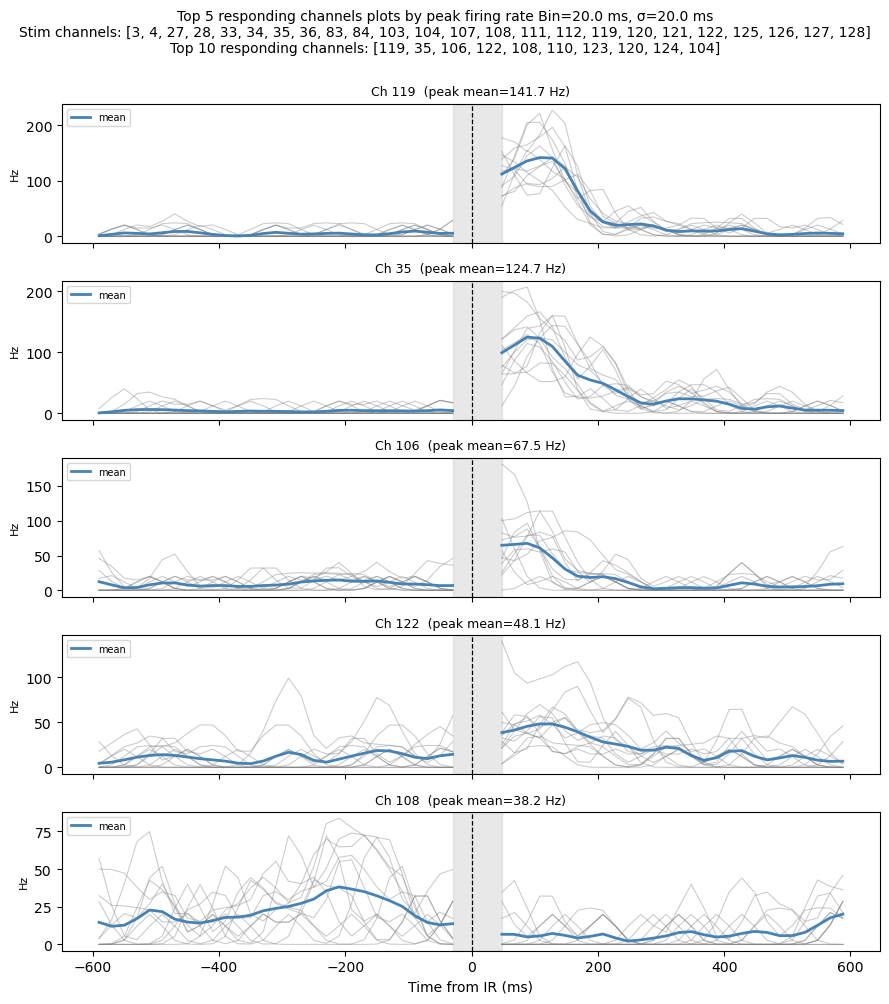

In [61]:
TOP_N_TITLE = 10
TOP_N_PLOT  = 5

stim_channels = stim_npz['nprw_meta'].item()['stim_channels']
stim_ch_str = ", ".join(map(str, stim_channels))

# rank by peak of trial-averaged PSTH in raw Hz
psth_hz = np.nanmean(rates_ch_hz, axis=0)  # (128, n_bins)
time_mask = (centers_ms >= -300) & (centers_ms <= 300)
peak_hz = np.nanmax(psth_hz[:, time_mask], axis=1)  # (128,)
top_idx_hz = np.argsort(peak_hz)[::-1][:TOP_N_TITLE]

top_ch_str = ", ".join(map(str, top_idx_hz))

# detect gap in bin centers (stim period removed)
dt = np.diff(centers_ms)
gap_idx = int(np.argmax(dt > dt.mean() * 3)) + 1
t_pre  = centers_ms[:gap_idx]
t_post = centers_ms[gap_idx:]

fig, axes = plt.subplots(TOP_N_PLOT, 1, figsize=(9, 2 * TOP_N_PLOT), sharex=True)
if TOP_N_PLOT == 1:
    axes = [axes]

for i, (ax, ch_idx) in enumerate(zip(axes, top_idx_hz[:TOP_N_PLOT])):
    ch_trials = rates_ch_hz[:, ch_idx, :]
    mean_trace = np.nanmean(ch_trials, axis=0)

    for trial in range(ch_trials.shape[0]):
        ax.plot(t_pre,  ch_trials[trial, :gap_idx], color="gray", alpha=0.4, linewidth=0.8)
        ax.plot(t_post, ch_trials[trial, gap_idx:], color="gray", alpha=0.4, linewidth=0.8)

    ax.plot(t_pre,  mean_trace[:gap_idx], color="steelblue", linewidth=2.0)
    ax.plot(t_post, mean_trace[gap_idx:], color="steelblue", linewidth=2.0, label="mean")

    ax.axvspan(t_pre[-1], t_post[0], color="lightgray", alpha=0.5, zorder=0)
    ax.axvline(0, linestyle="--", color="black", linewidth=0.9)
    ax.set_ylabel("Hz", fontsize=8)
    ax.set_title(f"Ch {ch_idx}  (peak mean={peak_hz[ch_idx]:.1f} Hz)", fontsize=9)
    ax.legend(loc="upper left", fontsize=7)

axes[-1].set_xlabel("Time from IR (ms)")
fig.suptitle(
    f"Top {TOP_N_PLOT} responding channels plots by peak firing rate Bin={BIN_MS} ms, σ={SIGMA_MS} ms\n"
    f"Stim channels: [{stim_ch_str}]\n"
    f"Top {TOP_N_TITLE} responding channels: [{top_ch_str}]",
    fontsize=10, y=1
)
plt.tight_layout()
plt.show()

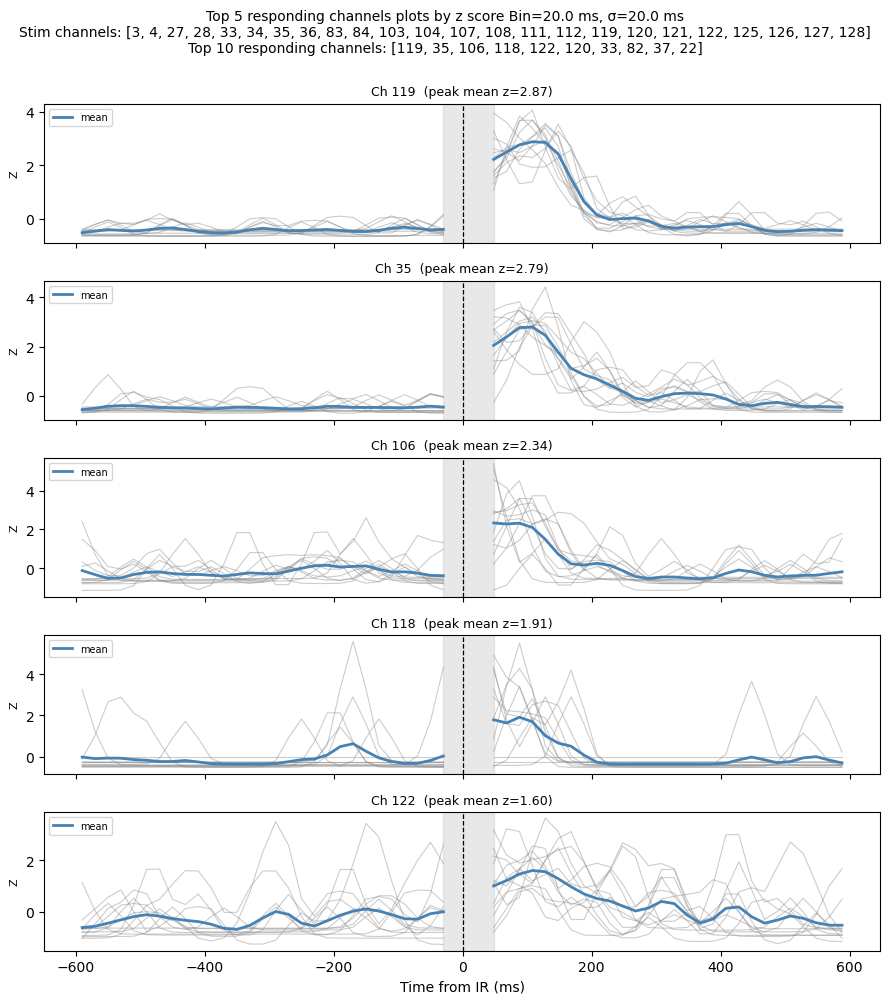

In [60]:
TOP_N_TITLE = 10
TOP_N_PLOT  = 5

stim_channels = stim_npz['nprw_meta'].item()['stim_channels']
stim_ch_str = ", ".join(map(str, stim_channels))

# rank by peak of trial-averaged z-score
psth_z_mean = np.nanmean(rates_ch_z, axis=0)  # (128, n_bins)
time_mask = (centers_ms >= -300) & (centers_ms <= 300)
peak_z = np.nanmax(psth_z_mean[:, time_mask], axis=1)  # (128,)
top_idx_z = np.argsort(peak_z)[::-1][:TOP_N_TITLE]

top_ch_str = ", ".join(map(str, top_idx_z))

# detect gap in bin centers (stim period removed)
dt = np.diff(centers_ms)
gap_idx = int(np.argmax(dt > dt.mean() * 3)) + 1
t_pre  = centers_ms[:gap_idx]
t_post = centers_ms[gap_idx:]

fig, axes = plt.subplots(TOP_N_PLOT, 1, figsize=(9, 2 * TOP_N_PLOT), sharex=True)
if TOP_N_PLOT == 1:
    axes = [axes]

for i, (ax, ch_idx) in enumerate(zip(axes, top_idx_z[:TOP_N_PLOT])):
    ch_trials = rates_ch_z[:, ch_idx, :]
    mean_trace = np.nanmean(ch_trials, axis=0)

    for trial in range(ch_trials.shape[0]):
        ax.plot(t_pre,  ch_trials[trial, :gap_idx], color="gray", alpha=0.4, linewidth=0.8)
        ax.plot(t_post, ch_trials[trial, gap_idx:], color="gray", alpha=0.4, linewidth=0.8)

    ax.plot(t_pre,  mean_trace[:gap_idx], color="steelblue", linewidth=2.0)
    ax.plot(t_post, mean_trace[gap_idx:], color="steelblue", linewidth=2.0, label="mean")

    ax.axvspan(t_pre[-1], t_post[0], color="lightgray", alpha=0.5, zorder=0)
    ax.axvline(0, linestyle="--", color="black", linewidth=0.9)
    ax.set_ylabel("Z", fontsize=8)
    ax.set_title(f"Ch {ch_idx}  (peak mean z={peak_z[ch_idx]:.2f})", fontsize=9)
    ax.legend(loc="upper left", fontsize=7)

axes[-1].set_xlabel("Time from IR (ms)")
fig.suptitle(
    f"Top {TOP_N_PLOT} responding channels plots by z score Bin={BIN_MS} ms, σ={SIGMA_MS} ms\n"
    f"Stim channels: [{stim_ch_str}]\n"
    f"Top {TOP_N_TITLE} responding channels: [{top_ch_str}]",
    fontsize=10, y=1
)
plt.tight_layout()
plt.show()

In [62]:
centers_ms, edges_ms

(array([-590.        , -570.        , -550.        , -530.        ,
        -510.        , -490.        , -470.        , -450.        ,
        -430.        , -410.        , -390.        , -370.        ,
        -350.        , -330.        , -310.        , -290.        ,
        -270.        , -250.        , -230.        , -210.        ,
        -190.        , -170.        , -150.        , -130.        ,
        -110.        ,  -90.        ,  -70.        ,  -50.        ,
         -30.        ,   47.93333333,   67.93333333,   87.93333333,
         107.93333333,  127.93333333,  147.93333333,  167.93333333,
         187.93333333,  207.93333333,  227.93333333,  247.93333333,
         267.93333333,  287.93333333,  307.93333333,  327.93333333,
         347.93333333,  367.93333333,  387.93333333,  407.93333333,
         427.93333333,  447.93333333,  467.93333333,  487.93333333,
         507.93333333,  527.93333333,  547.93333333,  567.93333333,
         587.93333333]),
 array([-600.        , 